# Agent 填色过程可视化

本笔记本复现游戏环境（与 App.tsx 使用相同的 PRNG 和地图生成逻辑），
然后运行 agent 并逐步可视化其填色决策。

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
from collections import defaultdict
import math
import ctypes

ROWS, COLS = 12, 20
COLORS = ['#F5FFFA', '#8a9a65', '#d4c473', '#9c7c64']  # MintCream, Green, Yellow, Brown
COLOR_NAMES = ['MintCream', 'Green', 'Yellow', 'Brown']
ROUND_SIZES = [20, 23, 26, 28, 31, 34, 37, 39, 42, 45]
ROUND_SEEDS = [42, 137, 256, 389, 512, 647, 783, 891, 1024, 1157]

## 1. 复现 mulberry32 PRNG 和地图生成

In [39]:
def _i32(x):
    """Truncate to signed 32-bit integer (JS |0 semantics)."""
    return ctypes.c_int32(x & 0xFFFFFFFF).value

def _u32(x):
    """Truncate to unsigned 32-bit integer."""
    return x & 0xFFFFFFFF

def _imul(a, b):
    """Emulate Math.imul: 32-bit integer multiply."""
    return _i32(a * b)

def mulberry32(seed):
    s = _i32(seed)
    def rand():
        nonlocal s
        s = _i32(s + 0x6D2B79F5)
        t = _imul(s ^ _u32(_u32(s) >> 15), _i32(1 | s))
        t = _i32(t + _imul(t ^ _u32(_u32(t) >> 7), _i32(61 | t))) ^ t
        return _u32(t ^ _u32(_u32(t) >> 14)) / 4294967296
    return rand

def generate_map(num_regions, rng):
    grid = [[-1] * COLS for _ in range(ROWS)]
    regions = []  # list of list of (r, c)

    for i in range(num_regions):
        while True:
            r = int(rng() * ROWS)
            c = int(rng() * COLS)
            if grid[r][c] == -1:
                break
        grid[r][c] = i
        regions.append([(r, c)])

    changed = True
    while changed:
        changed = False
        for i in range(num_regions):
            neighbors = []
            for (r, c) in regions[i]:
                for dr, dc in [(0,1),(1,0),(0,-1),(-1,0)]:
                    nr, nc = r+dr, c+dc
                    if 0 <= nr < ROWS and 0 <= nc < COLS and grid[nr][nc] == -1:
                        neighbors.append((nr, nc))
            if neighbors:
                nr, nc = neighbors[int(rng() * len(neighbors))]
                if grid[nr][nc] == -1:
                    grid[nr][nc] = i
                    regions[i].append((nr, nc))
                    changed = True

    for r in range(ROWS):
        for c in range(COLS):
            if grid[r][c] == -1:
                for dr, dc in [(0,1),(1,0),(0,-1),(-1,0)]:
                    nr, nc = r+dr, c+dc
                    if 0 <= nr < ROWS and 0 <= nc < COLS and grid[nr][nc] != -1:
                        grid[r][c] = grid[nr][nc]
                        regions[grid[nr][nc]].append((r, c))
                        break

    adjacency = defaultdict(set)
    for r in range(ROWS):
        for c in range(COLS):
            for dr, dc in [(0,1),(1,0)]:
                nr, nc = r+dr, c+dc
                if nr < ROWS and nc < COLS:
                    if grid[r][c] != grid[nr][nc]:
                        adjacency[grid[r][c]].add(grid[nr][nc])
                        adjacency[grid[nr][nc]].add(grid[r][c])

    return grid, regions, adjacency

## 2. Agent 逻辑

In [40]:
def centroid_distance(cells):
    cy, cx = ROWS / 2, COLS / 2
    avg_r = sum(r for r, c in cells) / len(cells)
    avg_c = sum(c for r, c in cells) / len(cells)
    return math.hypot(avg_r - cy, avg_c - cx)

def agent_solve(regions, adjacency, colors):
    n = len(regions)
    current_colors = [None] * n
    steps = []

    for step_num in range(1, n + 1):
        uncolored = [i for i in range(n) if current_colors[i] is None]
        if not uncolored:
            break

        def sort_key(rid):
            colored_nbrs = sum(1 for nb in adjacency[rid] if current_colors[nb] is not None)
            return (-colored_nbrs, centroid_distance(regions[rid]))

        uncolored.sort(key=sort_key)
        chosen = uncolored[0]

        used = {current_colors[nb] for nb in adjacency[chosen] if current_colors[nb] is not None}
        color = next((c for c in colors if c not in used), colors[0])

        colored_nbrs = sum(1 for nb in adjacency[chosen] if current_colors[nb] is not None)
        total_nbrs = len(adjacency[chosen])
        dist = centroid_distance(regions[chosen])

        steps.append({
            'step': step_num,
            'region': chosen,
            'color': color,
            'colored_neighbors': colored_nbrs,
            'total_neighbors': total_nbrs,
            'center_dist': dist,
        })
        current_colors[chosen] = color

    return steps, current_colors

## 3. 可视化函数

In [41]:
UNCOLORED = '#e0e0e0'
HIGHLIGHT_EDGE = '#ff0000'

def draw_grid(ax, grid, regions, region_colors, highlight_region=None, step_info=None):
    """Draw the colored grid. highlight_region gets a red border."""
    img = np.zeros((ROWS, COLS, 4))
    for r in range(ROWS):
        for c in range(COLS):
            rid = grid[r][c]
            color = region_colors[rid] if region_colors[rid] else UNCOLORED
            img[r, c] = to_rgba(color)

    ax.imshow(img, interpolation='nearest', aspect='equal')

    # Draw region borders
    for r in range(ROWS):
        for c in range(COLS):
            for dr, dc in [(0,1),(1,0)]:
                nr, nc = r+dr, c+dc
                if nr < ROWS and nc < COLS and grid[r][c] != grid[nr][nc]:
                    if dc == 1:  # vertical border
                        ax.plot([c+0.5, c+0.5], [r-0.5, r+0.5], color='#666', linewidth=0.5)
                    else:  # horizontal border
                        ax.plot([c-0.5, c+0.5], [r+0.5, r+0.5], color='#666', linewidth=0.5)

    # Highlight chosen region
    if highlight_region is not None:
        cells = set(regions[highlight_region])
        for (r, c) in regions[highlight_region]:
            for dr, dc in [(0,1),(1,0),(0,-1),(-1,0)]:
                nr, nc = r+dr, c+dc
                if (nr, nc) not in cells or nr < 0 or nr >= ROWS or nc < 0 or nc >= COLS:
                    # draw edge
                    if dc == 1:
                        ax.plot([c+0.5, c+0.5], [r-0.5, r+0.5], color=HIGHLIGHT_EDGE, linewidth=2)
                    elif dc == -1:
                        ax.plot([c-0.5, c-0.5], [r-0.5, r+0.5], color=HIGHLIGHT_EDGE, linewidth=2)
                    elif dr == 1:
                        ax.plot([c-0.5, c+0.5], [r+0.5, r+0.5], color=HIGHLIGHT_EDGE, linewidth=2)
                    elif dr == -1:
                        ax.plot([c-0.5, c+0.5], [r-0.5, r-0.5], color=HIGHLIGHT_EDGE, linewidth=2)

    # Region id labels
    for i, cells in enumerate(regions):
        avg_r = sum(r for r, c in cells) / len(cells)
        avg_c = sum(c for r, c in cells) / len(cells)
        ax.text(avg_c, avg_r, str(i), ha='center', va='center', fontsize=5, color='#333')

    if step_info:
        ax.set_title(step_info, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

## 4. 运行 Agent 并可视化（选择一个 round）

In [43]:
ROUND = 8  # 修改此值 (0-9) 可查看不同 round

rng = mulberry32(ROUND_SEEDS[ROUND])
grid, regions, adjacency = generate_map(ROUND_SIZES[ROUND], rng)
steps, final_colors = agent_solve(regions, adjacency, COLORS)

print(f'Round {ROUND}: {ROUND_SIZES[ROUND]} regions, {len(steps)} steps')
for s in steps:
    cname = COLOR_NAMES[COLORS.index(s["color"])] if s["color"] in COLORS else s["color"]
    print(f'  Step {s["step"]:2d}: Region {s["region"]:2d} -> {cname:6s}  '
          f'(colored neighbors: {s["colored_neighbors"]}/{s["total_neighbors"]}, '
          f'dist: {s["center_dist"]:.2f})')

Round 8: 42 regions, 42 steps
  Step  1: Region  7 -> MintCream  (colored neighbors: 0/6, dist: 0.56)
  Step  2: Region 18 -> Green   (colored neighbors: 1/5, dist: 2.30)
  Step  3: Region 20 -> Yellow  (colored neighbors: 2/6, dist: 3.71)
  Step  4: Region 16 -> Green   (colored neighbors: 2/5, dist: 3.04)
  Step  5: Region 31 -> Yellow  (colored neighbors: 2/7, dist: 3.00)
  Step  6: Region  0 -> Green   (colored neighbors: 2/6, dist: 3.24)
  Step  7: Region 12 -> Yellow  (colored neighbors: 3/5, dist: 4.07)
  Step  8: Region  1 -> MintCream  (colored neighbors: 2/5, dist: 4.30)
  Step  9: Region 11 -> Brown   (colored neighbors: 3/6, dist: 4.53)
  Step 10: Region  8 -> MintCream  (colored neighbors: 3/7, dist: 6.45)
  Step 11: Region 28 -> MintCream  (colored neighbors: 2/5, dist: 4.40)
  Step 12: Region 13 -> Yellow  (colored neighbors: 3/5, dist: 6.52)
  Step 13: Region 30 -> MintCream  (colored neighbors: 2/4, dist: 4.81)
  Step 14: Region  3 -> Brown   (colored neighbors: 3/7, d

## 5. 逐步可视化

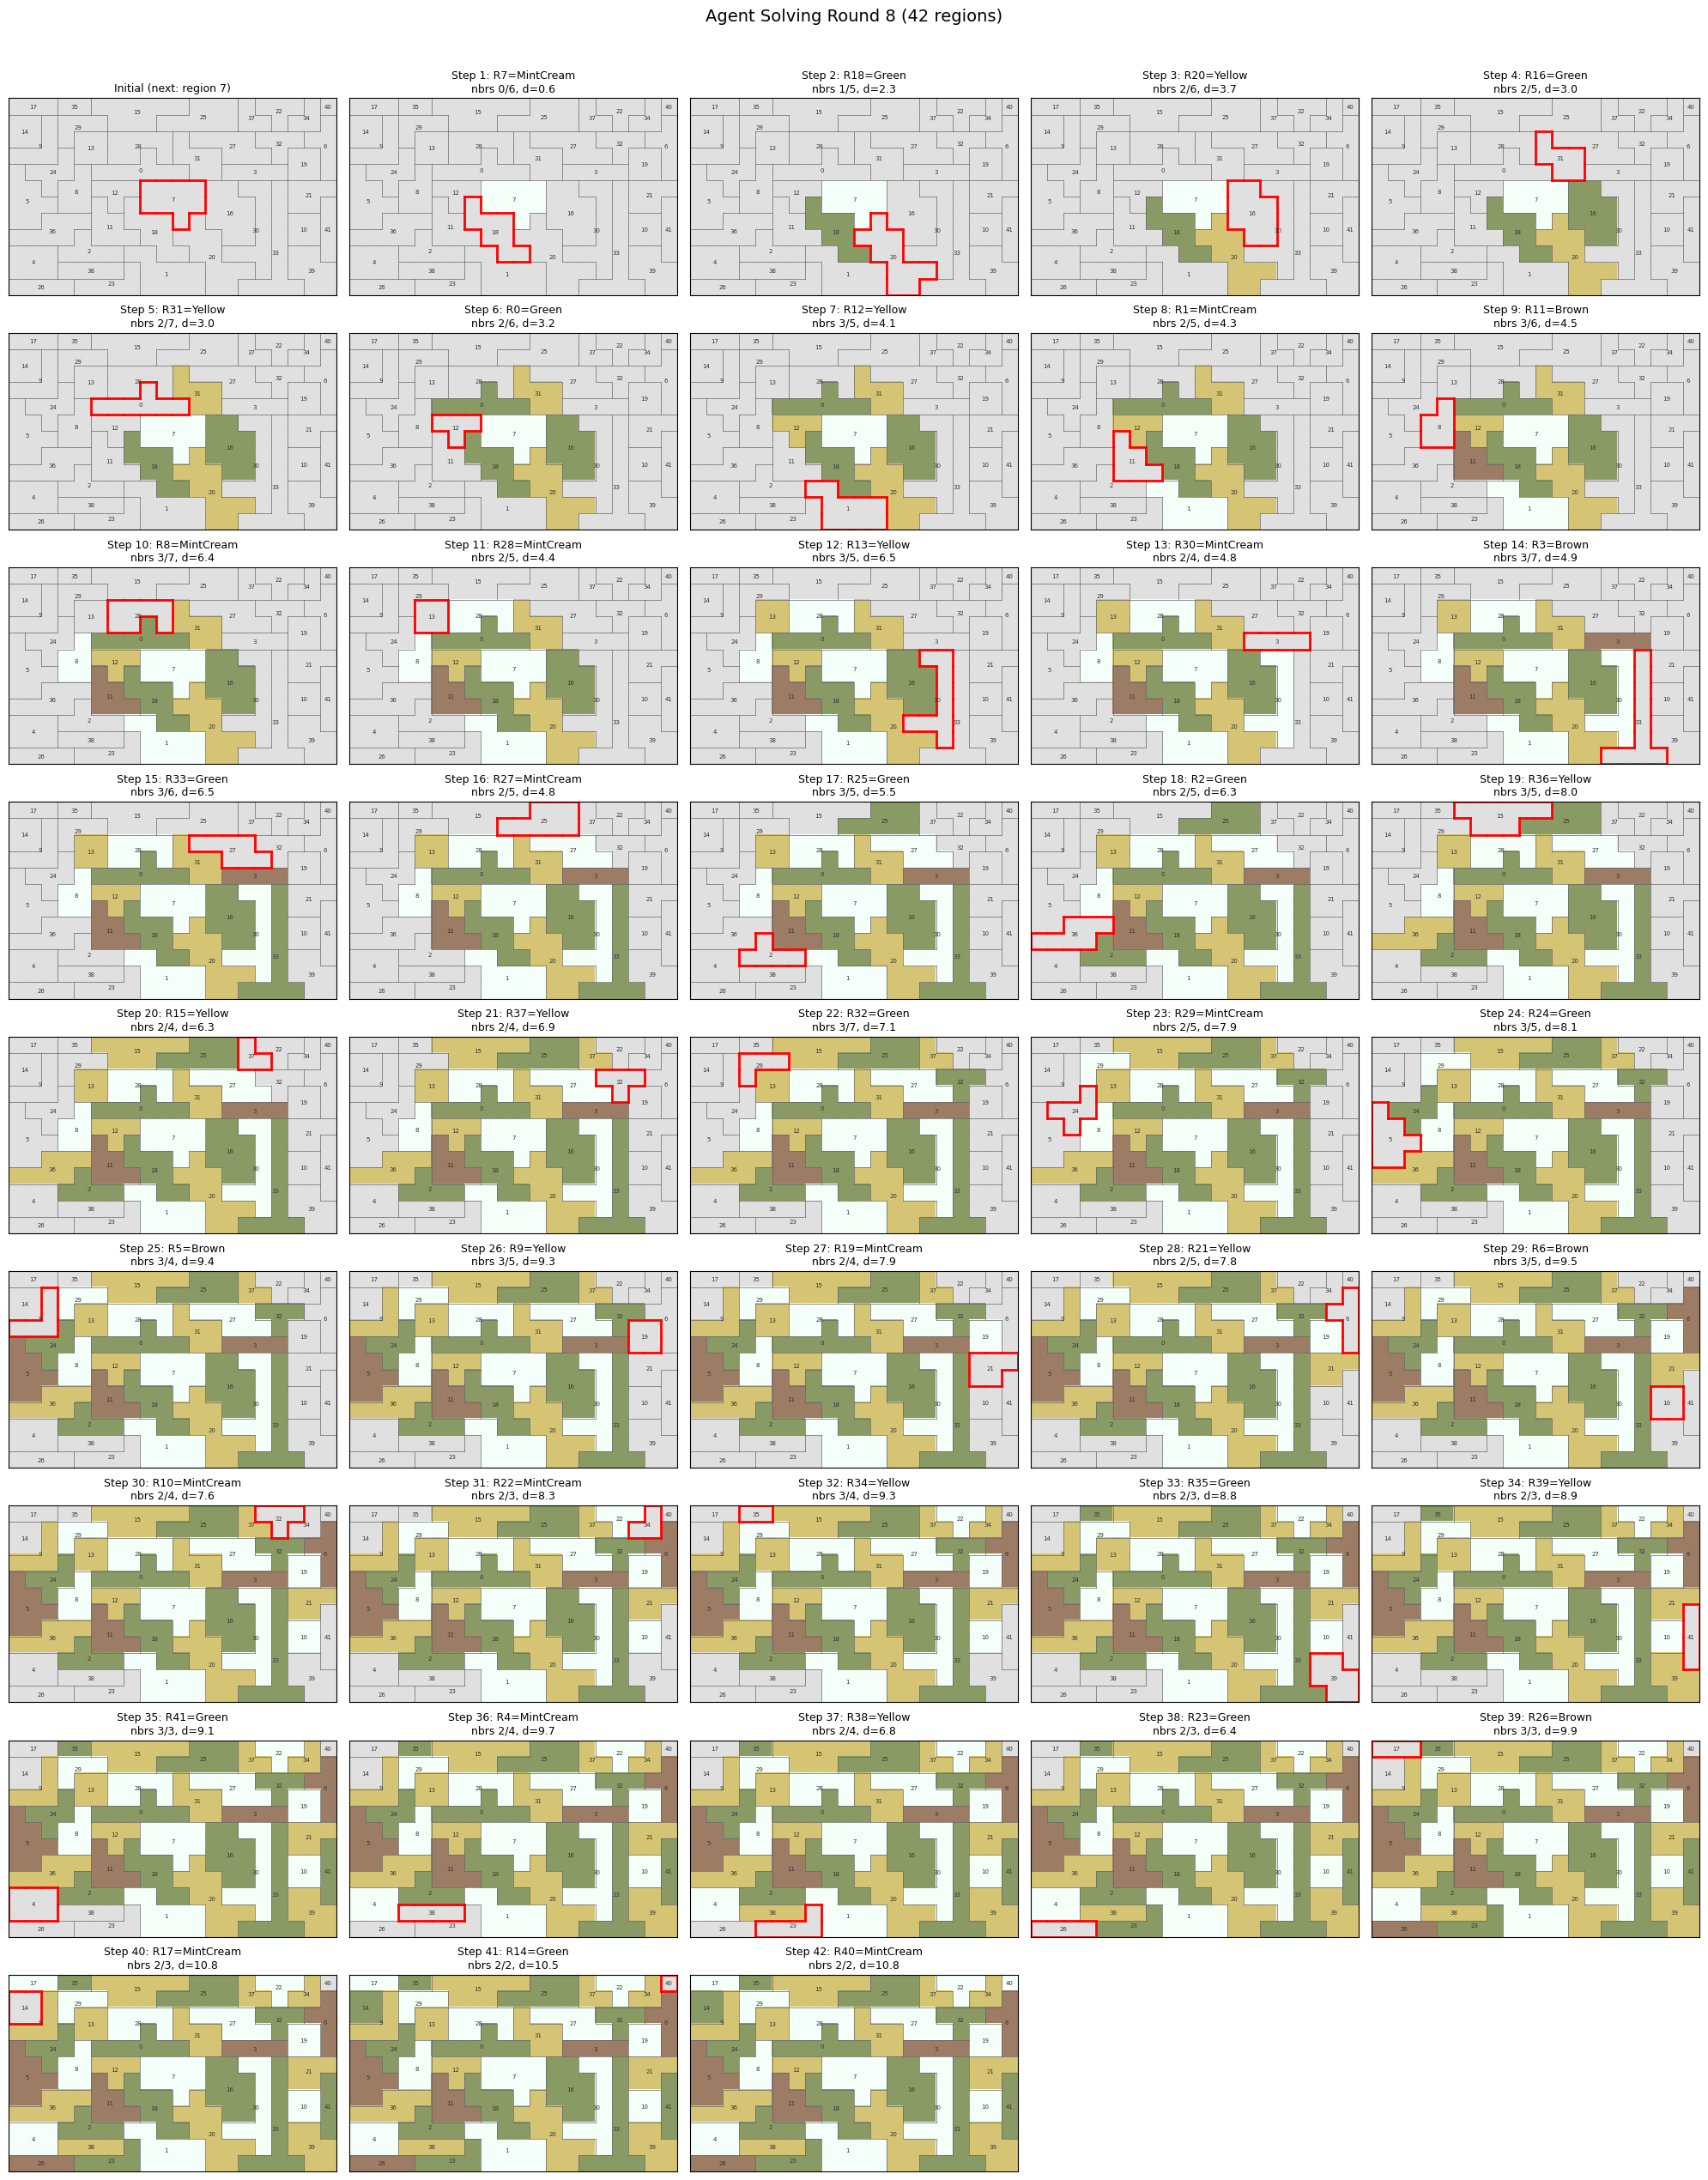

In [44]:
n_steps = len(steps)
cols_per_row = 5
n_rows = math.ceil((n_steps + 1) / cols_per_row)  # +1 for initial blank state

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(cols_per_row * 4, n_rows * 2.8))
axes = axes.flatten()

# Initial state
colors_state = [None] * len(regions)
draw_grid(axes[0], grid, regions, colors_state,
          highlight_region=steps[0]['region'],
          step_info='Initial (next: region {})'.format(steps[0]['region']))

# Each step
for idx, s in enumerate(steps):
    colors_state[s['region']] = s['color']
    cname = COLOR_NAMES[COLORS.index(s['color'])] if s['color'] in COLORS else '?'
    next_region = steps[idx + 1]['region'] if idx + 1 < len(steps) else None
    info = (f'Step {s["step"]}: R{s["region"]}={cname}\n'
            f'nbrs {s["colored_neighbors"]}/{s["total_neighbors"]}, d={s["center_dist"]:.1f}')
    draw_grid(axes[idx + 1], grid, regions, colors_state,
              highlight_region=next_region, step_info=info)

# Hide unused axes
for i in range(n_steps + 1, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(f'Agent Solving Round {ROUND} ({ROUND_SIZES[ROUND]} regions)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. 验证：检查最终着色是否有冲突

In [45]:
conflicts = []
for rid in range(len(regions)):
    for nb in adjacency[rid]:
        if final_colors[rid] == final_colors[nb]:
            conflicts.append((rid, nb))

if conflicts:
    print(f'Found {len(conflicts)//2} conflicts:')
    seen = set()
    for a, b in conflicts:
        pair = (min(a,b), max(a,b))
        if pair not in seen:
            seen.add(pair)
            print(f'  Region {a} and Region {b} both have {final_colors[a]}')
else:
    print('No conflicts! Agent solved the puzzle correctly.')

No conflicts! Agent solved the puzzle correctly.
